### [ 연속영역분할1: 거리변환 ] <hr>
- 작은 이진 이미지를 만들어 각 전경 픽셀이 가장 가까운 배경까지 얼마나 떨어져있는지 확인
- 배경 픽셀: 0
- 전경 픽셀: 255
- 중심으로 갈수록 거리 값 커짐

In [ ]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")

import importlib
import cv_utils

importlib.reload(cv_utils)




- [1] 임의 픽셀로 이진 이미지 만들기

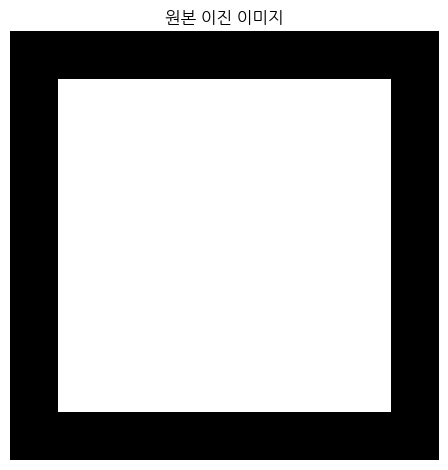

In [40]:
## ---------------------------------------------------
## 좌우상하- 배경으로 0
## 가운데- 전경으로 255
## ---------------------------------------------------

imageNP=np.zeros((9,9), dtype=np.uint8)
imageNP[1:8, 1:8]= 255

printPlots(1, 1, ["원본 이진 이미지"], [imageNP], ['gray'])

In [41]:
## => 변환 방식 : cv2.DIST_L2
distanceNP = cv2.distanceTransform(imageNP, cv2.DIST_L2, 5)
print("거리 변환 결과", distanceNP)

## => 시각화
printDistance(imageNP, distanceNP, "이전 이미지 + 거리변환값")

거리 변환 결과 [[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [0. 1. 2. 2. 2. 2. 2. 1. 0.]
 [0. 1. 2. 3. 3. 3. 2. 1. 0.]
 [0. 1. 2. 3. 4. 3. 2. 1. 0.]
 [0. 1. 2. 3. 3. 3. 2. 1. 0.]
 [0. 1. 2. 2. 2. 2. 2. 1. 0.]
 [0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]


NameError: name 'printDistance' is not defined

### [핵심 정리] <hr>

- 거리 변환은 객체 내부에서 배경으로부터 가장 먼 부분을 찾는 데 유용

- 활용 예:
  * 객체 중심점 찾기
  * 손바닥 중심 찾기
  * 서로 붙은 객체를 워터셰드로 분리하기 위한 전경 마커 생성